# ODE integrators

## The problem

We will again consider the collective Ising spin-model with a transverse field, as in programming exercise 5, which is governed by the Hamiltonian
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. We studied this model in detail on the previous exercise sheet using exact diagonalization. Now we want to test how different numerical integrators perform on this problem and use exact diagonalziation as a benchmark.

In [1]:
import sys
sys.path.append("..")

# load standard libraries
import numpy as np   # standard numerics library
import numpy.linalg as LA
from scipy.integrate import ode


import matplotlib.pyplot as plt   # for making plots

import time as time

import scipy.sparse as sparse
import scipy.sparse.linalg as sLA

import Comp_Quant_Dynam as cqd

### Exercise 1

Now we want to use different integrators to see how they perform. A code for testing the Euler method has already been implemeted for you. Run it and describe your observations. Play with the step size in the 1st part.

In this exercise you don't need to code but just understand the given code and play with it.

Overall, you should try to answer the following questions:
- How does the global error of Euler scale with dt?
- What dt is needed to obtain $S_x$ at $t=10$ with an absolute error of less than 0.1?
- How does the norm grow in time? What does this tell us about stability?
- How do the deviations from the exact solution behave for the different observables? Oscillate around the exact value of deviate from it monotonically?
- How does the stability depend on the atom number? How can we interpret this in terms of the stiffness of the problem?

Calculate ED result.

In [2]:
dtout = 0.1
tend = 10
tsteps = int(np.round(tend / dtout))
tvec_output = cqd.utility.create_tvecs(tsteps, dtout)
#tvec_output = tvec_ED
ome = 0.6

N = 20
ini = np.eye(1, N + 1, 0)[0]

# set up observables and Hamiltonian
Sz = cqd.operators.Sz_sparse(N)
Sx = cqd.operators.Sx_sparse(N)
S_eye = sparse.identity(N+1, format='csr')
obsv_vec = [Sz, Sx, S_eye]

H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)

observables_ED = cqd.unitaries.calc_expv_ED(obsv_vec, H_mat, ini, tvec_output)

time for ED was 0.01702404022216797


Intergration with Euler:

Integrate with a given step size to study accuracy.

time for integration was 4.809141635894775


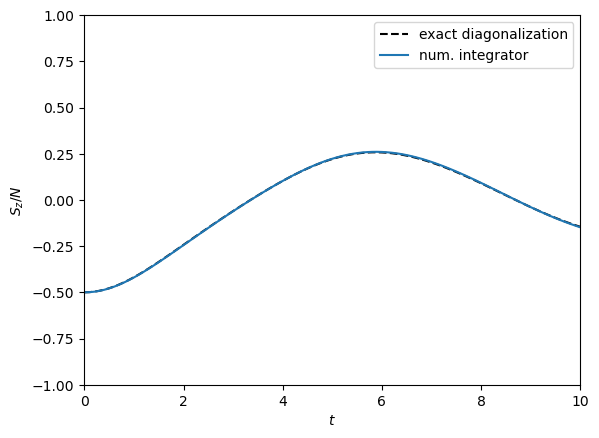

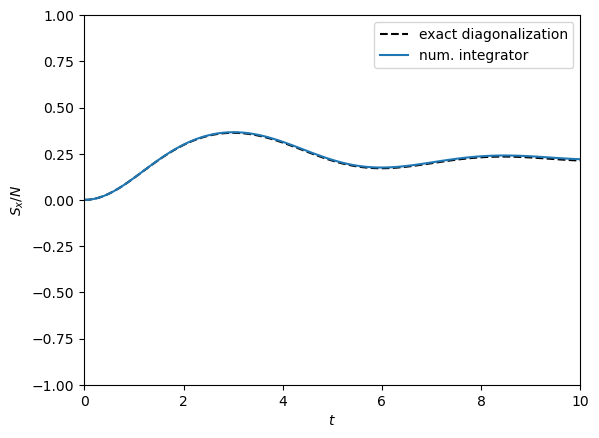

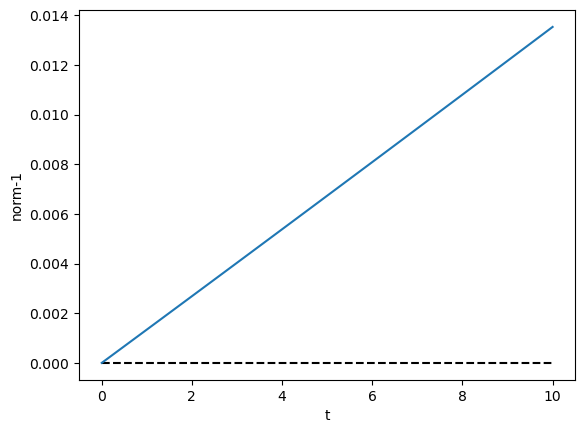

In [3]:
# choose integrator and time step
stepper_func = cqd.integrators.Euler_step
stepper_args = []

int_steps_per_dtout = 1000

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Next we want to loop over step size to see how error depends on it.

In [4]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 11
stepper = cqd.integrators.Euler_step
stepper_args = []

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.02287888526916504
dt_integrator =  0.1
time for integration was 0.029326438903808594
dt_integrator =  0.05
time for integration was 0.023375749588012695
dt_integrator =  0.025
time for integration was 0.038294076919555664
dt_integrator =  0.0125
time for integration was 0.0574193000793457
dt_integrator =  0.00625


/home/f73aeabd-6de4-471d-92a9-1ba552ae6153/QuantumDynamicsLab/Solutions/../Comp_Quant_Dynam/integrators.py:51: UserWarning: Some observables have non-zero imaginary parts
  warnings.warn("Some observables have non-zero imaginary parts")


time for integration was 0.09583520889282227
dt_integrator =  0.003125
time for integration was 0.1763591766357422
dt_integrator =  0.0015625
time for integration was 0.4883551597595215
dt_integrator =  0.00078125
time for integration was 0.7692272663116455
dt_integrator =  0.000390625
time for integration was 1.2469456195831299
dt_integrator =  0.0001953125
time for integration was 3.26910400390625
dt_integrator =  9.765625e-05
time for integration was 5.384019136428833


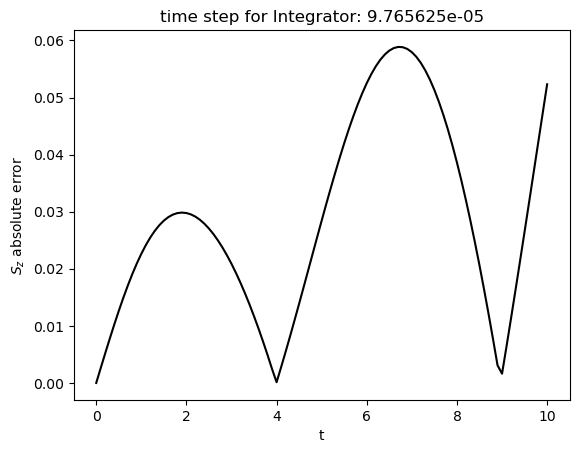

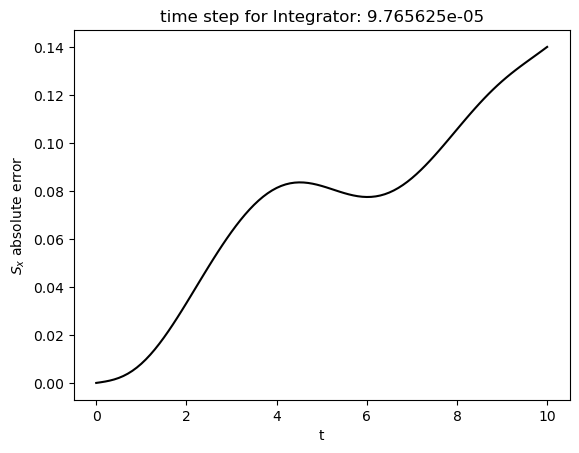

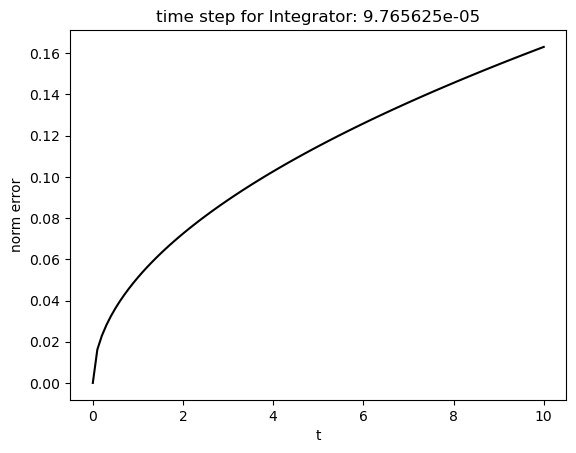

In [5]:
idx_stepsize = -1

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Plot deviation as function of step size. Use a double log scale.

Here, use the deviation of $S_x$ at the end time as an indicator for accuracy. One could also use other observables. If an observable oscillates in time around the exact value, it is better to use a time average over some time interval to quantify the error.

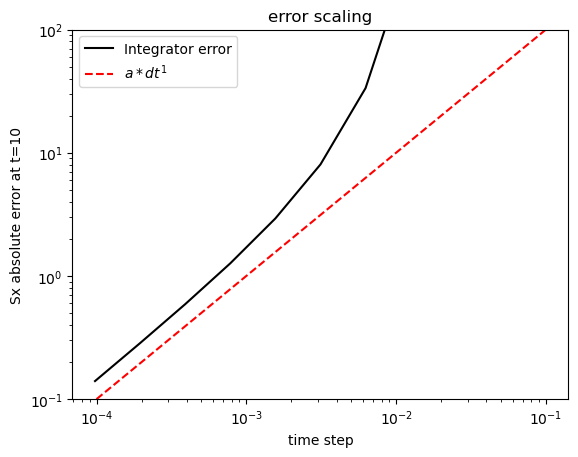

In [6]:
plt.loglog(step_sizes, deviations[:, 1, -1], 'k') # plot the error at the final time for Sx ([:, 1, -1]) as a function of the time step size on a log-log scale
plt.loglog(step_sizes,10 ** 3 * step_sizes, 'r--') # linear scaling for comparison (the prefactor 10**3 is just to make the line visible in the plot, you can adjust it as needed)
plt.title('error scaling')
plt.ylim([10 ** -1, 10 ** 2]) # Euler N=20
plt.legend(['Integrator error','$a*dt^1$'])
plt.xlabel('time step')
plt.ylabel('Sx absolute error at t=10')
plt.show()

Conclusions for Euler: 

We confirmed that the Euler integrator has global error that scales linearly with the time step size.

To reach an absolute error on the order of 0.1 in $S_x$ after t=10 time units, we need a time step of $10^{-4}$, which is really poor.

If the time step is too large ($>10^{-2}$) Euler quickly diverges.

The norm always increases exponentially. Thus we see that this integrator is unstable!

For $S_z$ the Euler solution oscillates around the exact (ED) solution. For $S_x$ the deviations increase almost monotonically.

We used N=20. For larger atom numbers we would need even smaller step size to get to t=10 before the norm explodes. (The largest eigenvlaue of the Hamiltonian is approximately $N/4$, which means that the ODE system gets more stiff.)


### Exercise 2

Do a corresponding analysis for other integrators (specified below). Discuss your observations as above. All you need to change is the stepper function. What is the scaling of the error with the time step? Is the norm conserved?

Try the Crank Nicolson integrator, which is an implicit integrator. The scipy function `spsolve()` may be useful.

Implement and try out the Arnoldi integrator. A function that calculates the Krylov vectors and the Hamiltonian in Krylov space has been implemented for you already in `cqd.integrators.generate_krylov_subspace()`. A good refernce on the details of this is https://www.sciencedirect.com/science/article/pii/S0010465598000836
The wikipadia page on the Arnoldi iteration even has a python source code for constructing the Krylov vectors.
Typical values for the intergation order are $n=10...20$. As the evolution within Krylov space is not the bottleneck in terms of runtime (the construction of the Krylov vectors is much more costly for large Hilber space dimension), it is ok to use `expm()` for this.

For these integrators you should use at least $N=100$. With Euler, really tiny steps would be needed to prevent it from diverging in this case, but higher order integrators should do much better.

In [7]:
dtout = 0.1
tend = 10
tsteps = int(np.round(tend / dtout))
tvec_output = cqd.utility.create_tvecs(tsteps, dtout)
#tvec_output = tvec_ED
ome = 0.6

N = 100
ini = np.eye(1, N + 1, 0)[0]

# set up observables and Hamiltonian
Sz = cqd.operators.Sz_sparse(N)
Sx = cqd.operators.Sx_sparse(N)
S_eye = sparse.identity(N+1, format='csr')
obsv_vec = [Sz, Sx, S_eye]

H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)

observables_ED = cqd.unitaries.calc_expv_ED(obsv_vec, H_mat, ini, tvec_output)

time for ED was 0.02092146873474121


### RK2

time for integration was 0.38622403144836426


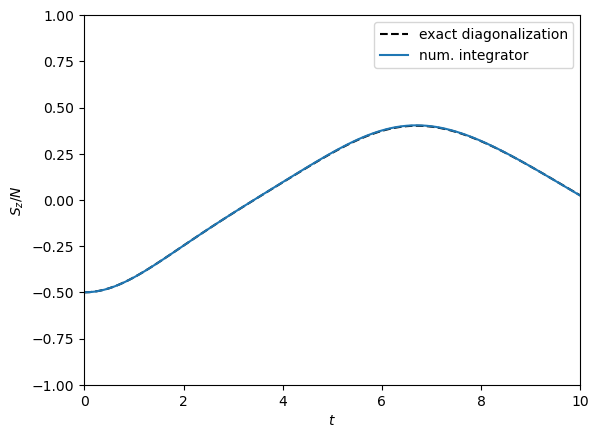

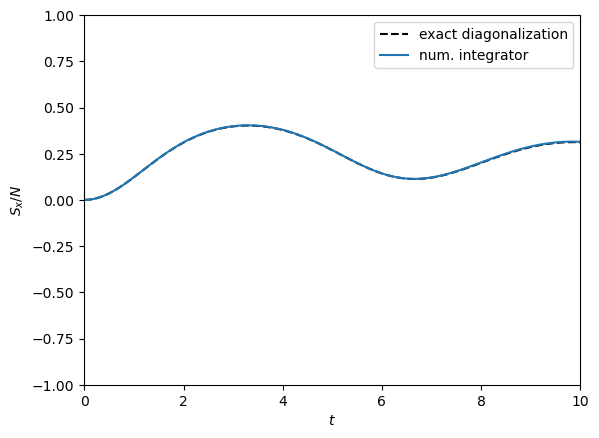

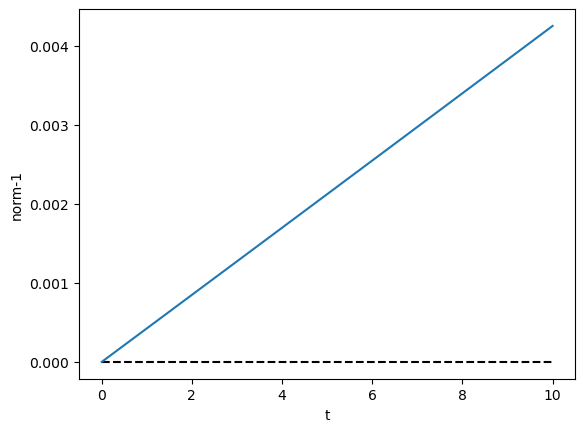

In [8]:
# second order Taylor expansion

stepper_func = cqd.integrators.RK2_step
stepper_args = []

int_steps_per_dtout = 50

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Loop over step size.

In [9]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 11
stepper = cqd.integrators.RK2_step
stepper_args = []

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.01893162727355957
dt_integrator =  0.1
time for integration was 0.020816564559936523
dt_integrator =  0.05
time for integration was 0.026324033737182617
dt_integrator =  0.025
time for integration was 0.04684853553771973
dt_integrator =  0.0125
time for integration was 0.07005786895751953
dt_integrator =  0.00625
time for integration was 0.13472580909729004
dt_integrator =  0.003125
time for integration was 0.22968101501464844
dt_integrator =  0.0015625
time for integration was 0.5673410892486572
dt_integrator =  0.00078125
time for integration was 0.9516193866729736
dt_integrator =  0.000390625
time for integration was 1.7440226078033447
dt_integrator =  0.0001953125
time for integration was 3.353771924972534
dt_integrator =  9.765625e-05
time for integration was 6.670997858047485


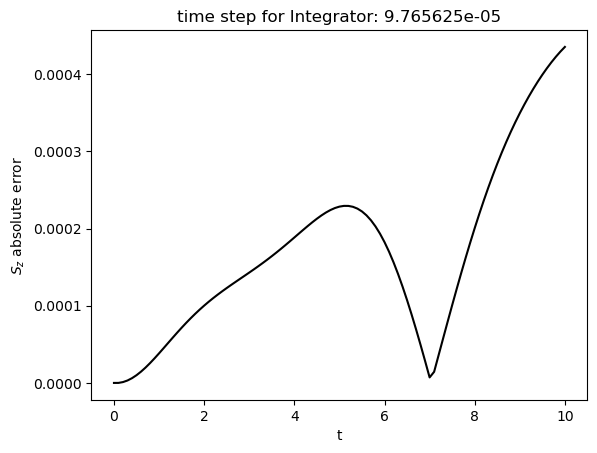

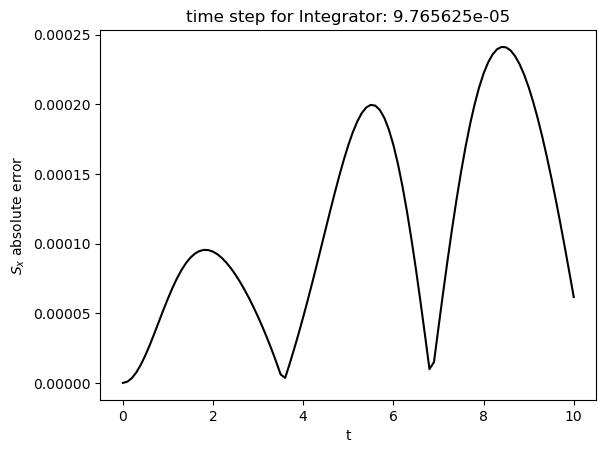

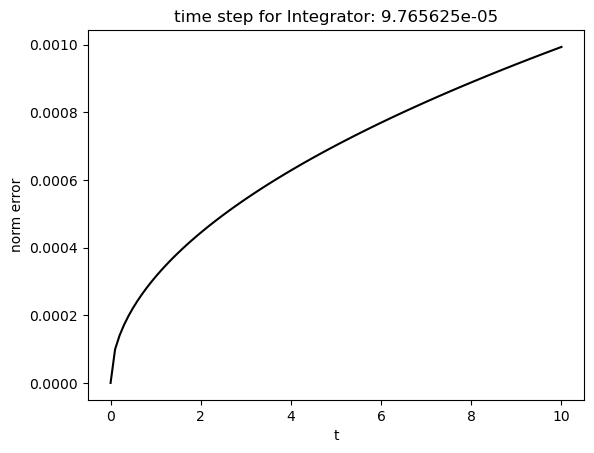

In [10]:
idx_stepsize = -1

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Plot deviation as function of step size.

Here, use the average deviation of $S_z$ (averaged over the second half of the simulated time window) as an indicator for accuracy.

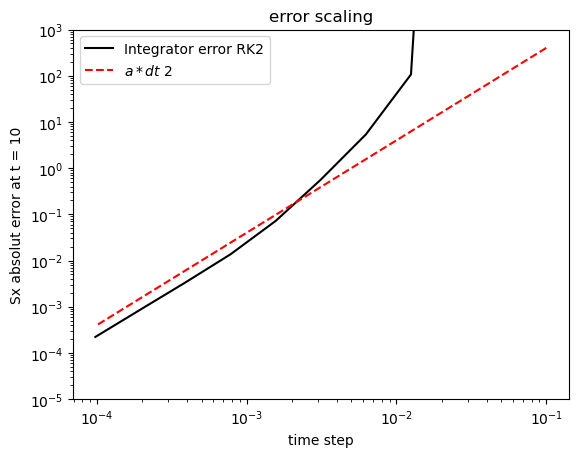

In [11]:
plt.loglog(step_sizes, np.mean(deviations[:, 0,int(len(tvec_output) / 2):], axis=1),'k')
plt.loglog(step_sizes,(2 * 10 ** 2 * step_sizes) ** 2, 'r--') # powerlaw "fit"
plt.title('error scaling')
plt.ylim([10 ** -5, 10 ** 3]) # 
plt.legend(['Integrator error RK2','$a * dt ^ 2$'])
plt.xlabel('time step')
plt.ylabel('Sx absolut error at t = 10')
plt.show()

### Crank Nicolson

time for integration was 5.229251384735107


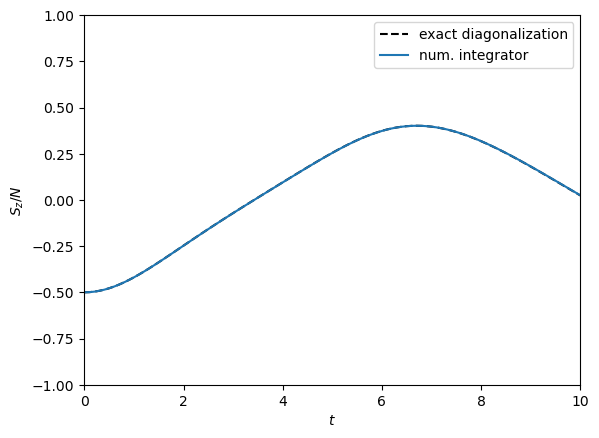

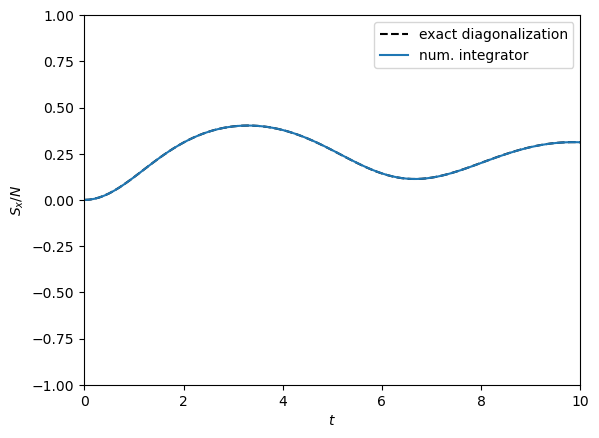

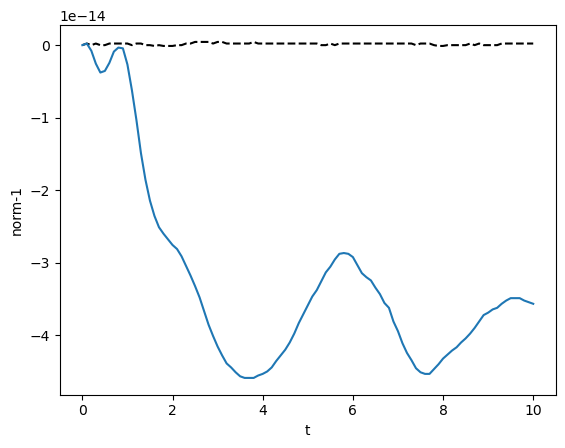

In [12]:
# Crank Nicolson

stepper_func = cqd.integrators.CN_step
stepper_args = []

int_steps_per_dtout = 50 # default for output time step is 0.1

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Loop over step size.

In [13]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 8
stepper = cqd.integrators.CN_step
stepper_args = []

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.020984411239624023
dt_integrator =  0.1
time for integration was 0.13263297080993652
dt_integrator =  0.05
time for integration was 0.25524139404296875
dt_integrator =  0.025
time for integration was 0.4773726463317871
dt_integrator =  0.0125
time for integration was 0.9472997188568115
dt_integrator =  0.00625
time for integration was 1.7334380149841309
dt_integrator =  0.003125
time for integration was 3.184666633605957
dt_integrator =  0.0015625
time for integration was 6.6719090938568115
dt_integrator =  0.00078125
time for integration was 13.057352066040039


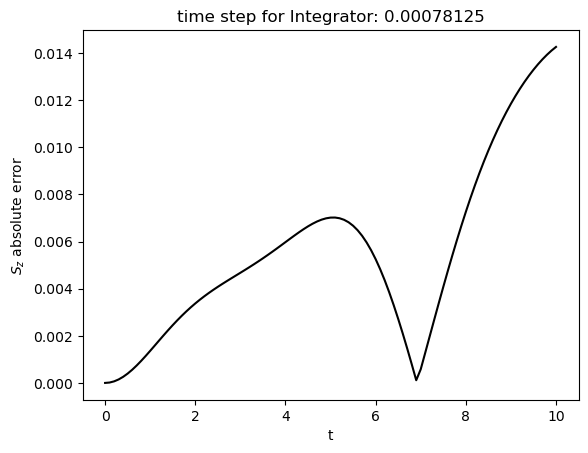

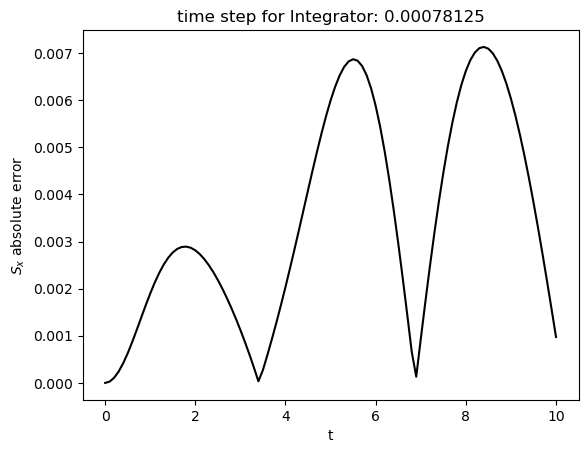

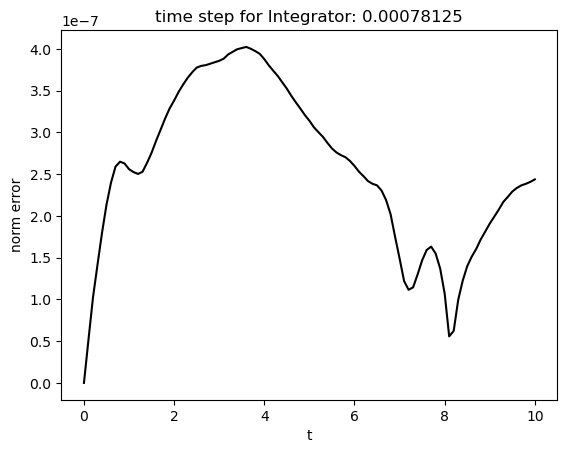

In [14]:
idx_stepsize = -1

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Plot deviation as function of step size.

Here, use the diviation of $S_x$ at the end time as an indicator for accuracy.

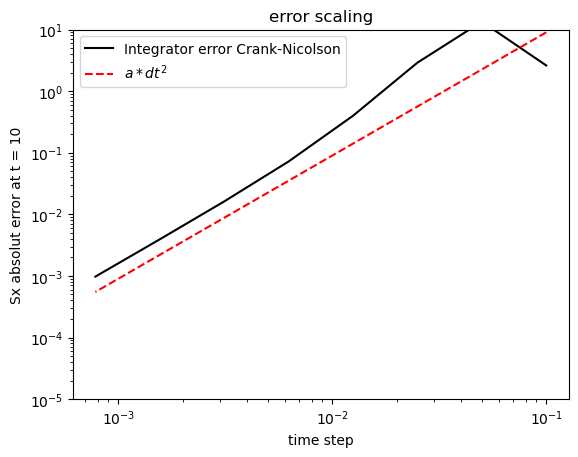

In [15]:
plt.loglog(step_sizes, deviations[:, 1, -1], 'k')
plt.loglog(step_sizes, (.3 * 10 ** 2 * step_sizes) ** 2, 'r--')
plt.title('error scaling')
plt.ylim([10 ** -5, 10 ** 1]) # 
plt.legend(['Integrator error Crank-Nicolson','$a * dt^2$'])
plt.xlabel('time step')
plt.ylabel('Sx absolut error at t = 10')
plt.show()

### RKn

time for integration was 0.11829686164855957


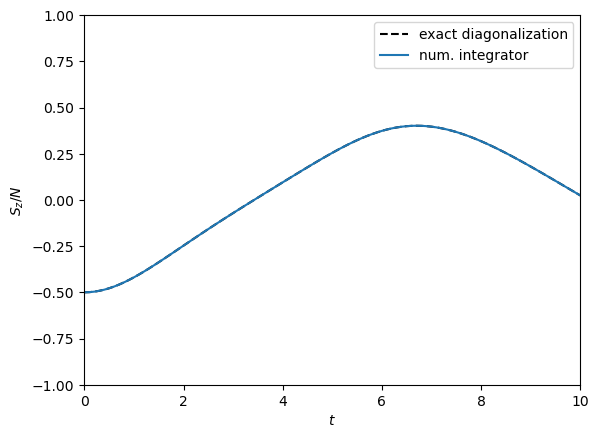

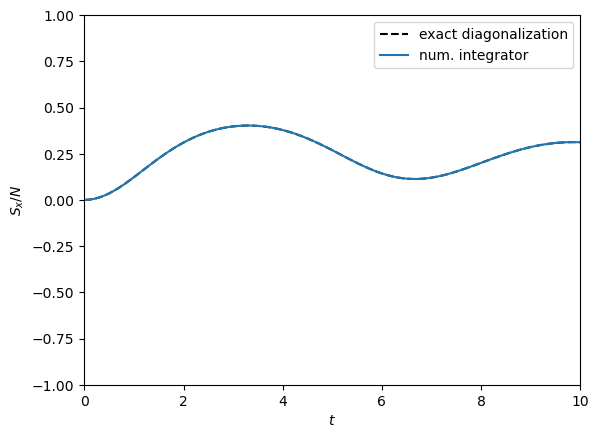

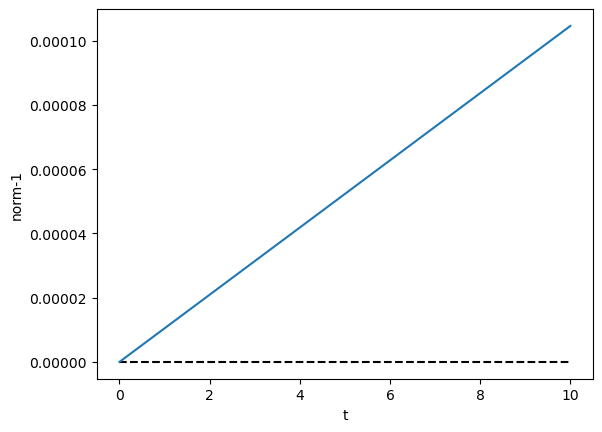

In [16]:
# second order Taylor expansion

stepper_func = cqd.integrators.RKn_step
n = 10
stepper_args = [n]

int_steps_per_dtout = 2

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Loop over step size.

In [17]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 10
stepper = cqd.integrators.RKn_step
stepper_args = [n]

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.022060394287109375
dt_integrator =  0.1
time for integration was 0.08940339088439941
dt_integrator =  0.05
time for integration was 0.1343526840209961
dt_integrator =  0.025
time for integration was 0.22765398025512695
dt_integrator =  0.0125
time for integration was 0.41704654693603516
dt_integrator =  0.00625
time for integration was 0.8206384181976318
dt_integrator =  0.003125
time for integration was 1.7198269367218018
dt_integrator =  0.0015625
time for integration was 3.6986639499664307
dt_integrator =  0.00078125
time for integration was 7.94707465171814
dt_integrator =  0.000390625
time for integration was 13.044313430786133
dt_integrator =  0.0001953125
time for integration was 26.41879892349243


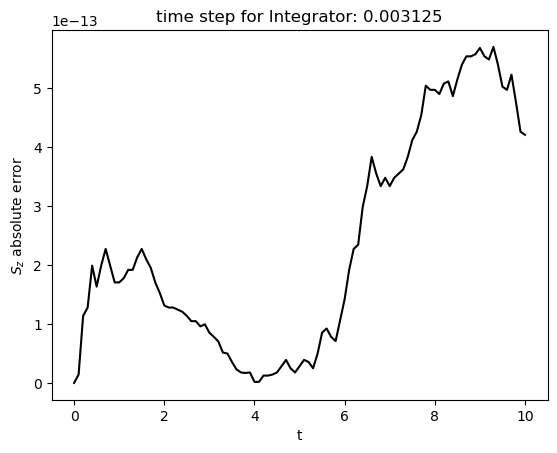

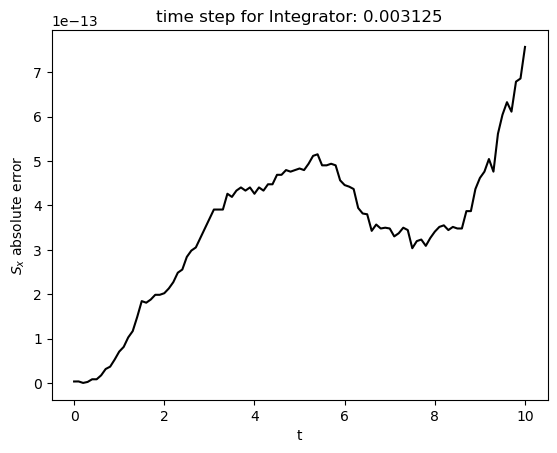

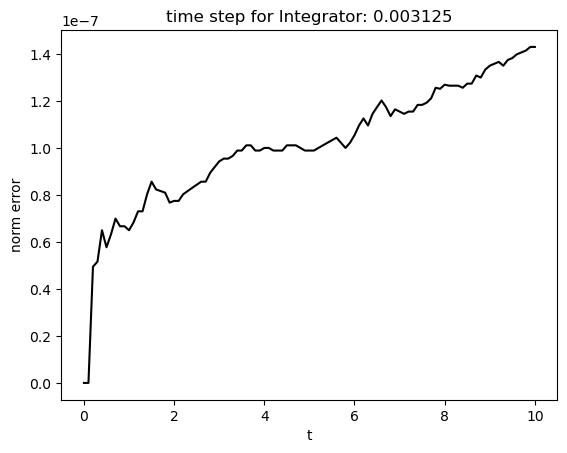

In [18]:
idx_stepsize = 5

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Deviation as function of step size. We use the time averaged deviation of $S_x$ to quantify the error.


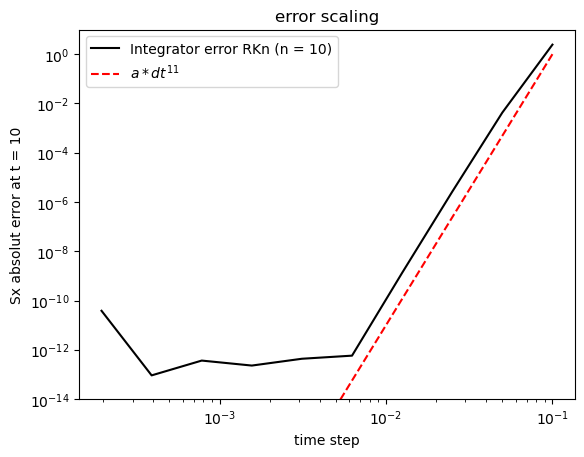

In [19]:
plt.loglog(step_sizes, np.mean(deviations[:, 1, 50:],axis=1),'k')
plt.loglog(step_sizes,(10 ** 1 * step_sizes) ** 11, 'r--')
plt.title('error scaling')
plt.ylim([10 ** -14, 10 ** 1]) # 
plt.legend(['Integrator error RKn (n = 10)','$a * dt^{11}$'])
plt.xlabel('time step')
plt.ylabel('Sx absolut error at t = 10')
plt.show()

### Arnoldi

time for integration was 0.42093491554260254


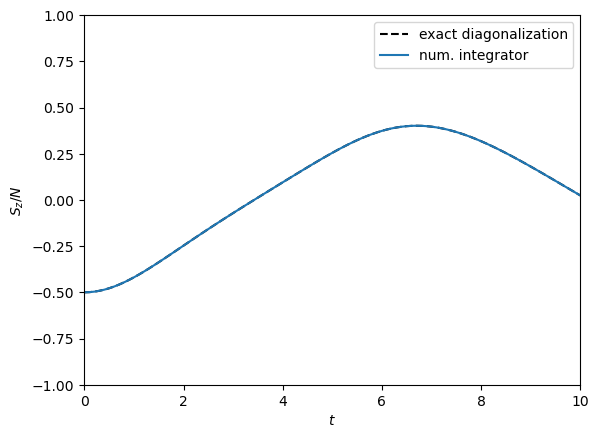

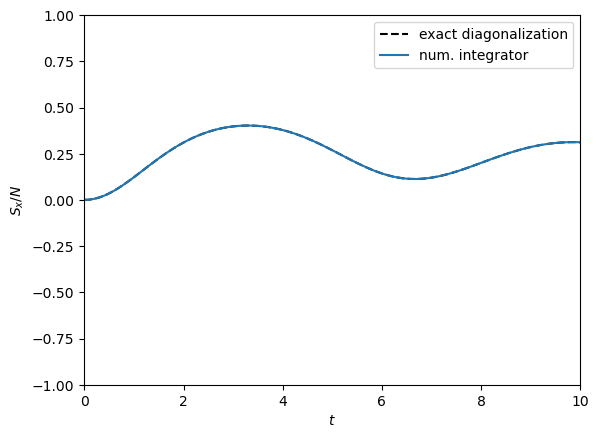

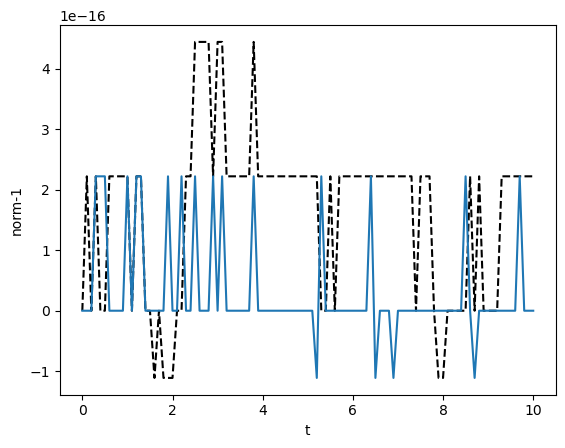

In [20]:
# Arnoldi

stepper_func = cqd.integrators.Arnoldi_step
n = 10
stepper_args = [n, N]

int_steps_per_dtout = 5

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Loop over step size.

In [21]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 8
stepper = cqd.integrators.Arnoldi_step
stepper_args = [n, N]

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.02078700065612793
dt_integrator =  0.1
time for integration was 0.11577534675598145
dt_integrator =  0.05
time for integration was 0.22623419761657715
dt_integrator =  0.025
time for integration was 0.31814074516296387
dt_integrator =  0.0125
time for integration was 0.5876185894012451
dt_integrator =  0.00625
time for integration was 1.2339129447937012
dt_integrator =  0.003125
time for integration was 2.5027873516082764
dt_integrator =  0.0015625
time for integration was 4.9567413330078125
dt_integrator =  0.00078125
time for integration was 10.153063297271729


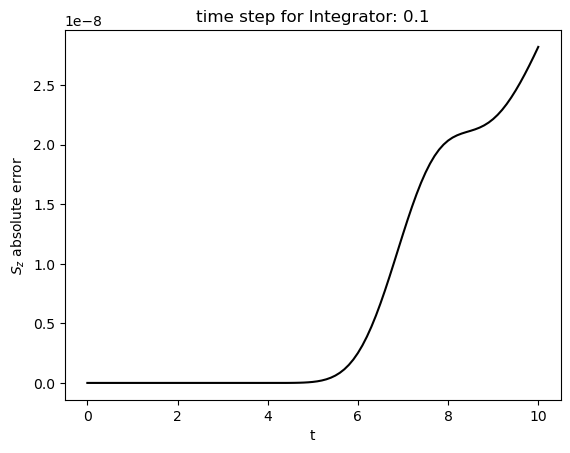

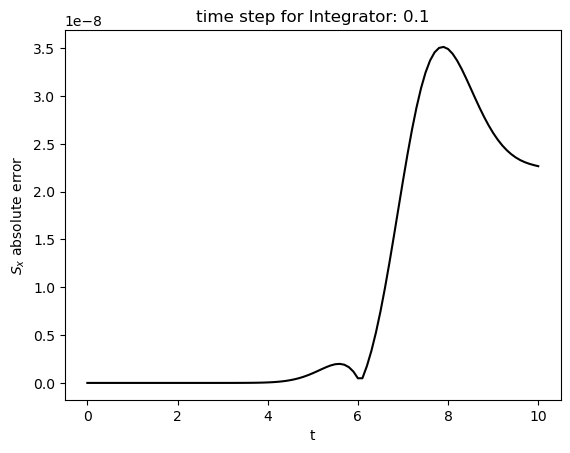

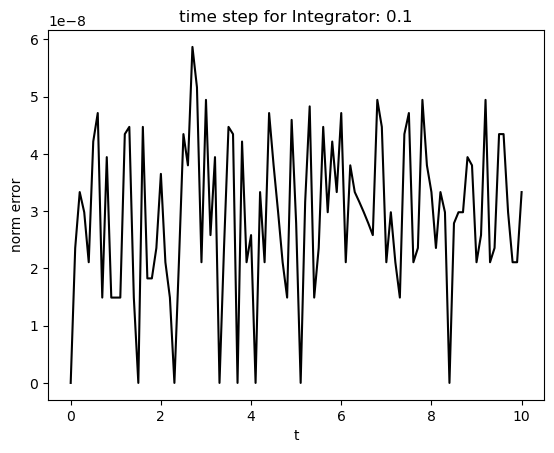

In [22]:
idx_stepsize = 0

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Error scaling with time step. We use the time averaged deviation of $S_x$ to quantify the error.

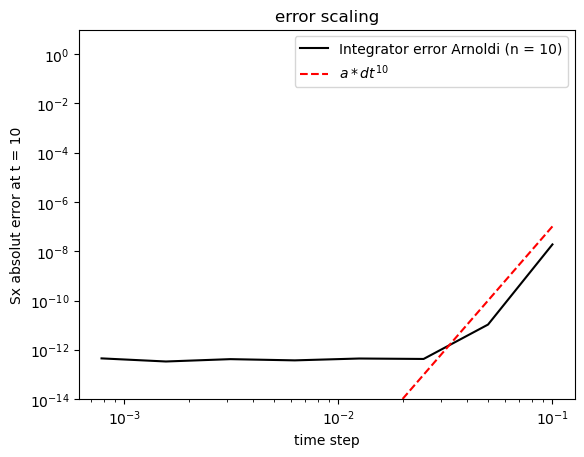

In [23]:
plt.loglog(step_sizes,np.mean(deviations[:, 1, 50:], axis=1), 'k')
plt.loglog(step_sizes,(2 * 10 ** 0 * step_sizes) ** 10, 'r--')
plt.title('error scaling')
plt.ylim([10 ** -14, 10 ** 1]) # 
plt.legend(['Integrator error Arnoldi (n = 10)','$a * dt^{10}$'])
plt.xlabel('time step')
plt.ylabel('Sx absolut error at t = 10')
plt.show()

For both integrators the norm is conserved. For CN the global error is order $dt^2$. For Arnoldi the global error scales like $dt^n$ with a very small prefactor. Quite large time steps are possible!

### Exercise 3

Now we want to use a numerical intergrator from the `scipy.integrate` module. For this I reccomend using the `ode` class which gives the best control of parameters and greatest choice of methods. The documentation is here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.ode.html#scipy.integrate.ode

The stepping with `ode` is typically done like this:

`r.integrate(r.t + dt)` <br>
`Psi = r.y`

Try different integrators and options to see how they perform in terms of speed and accuracy. Use a fixed particle number of N=100. Describe your observations. Example options are given below. Try to find something faster/more stable!

These integrators all use adaptive stepsize internally, so we don't have to analyze the step size dependence of the accuracy. They should in principle always give accurate results or otherwise give a warning message that the specified accuracy goal could not be reached.

time for integration was 0.5420835018157959


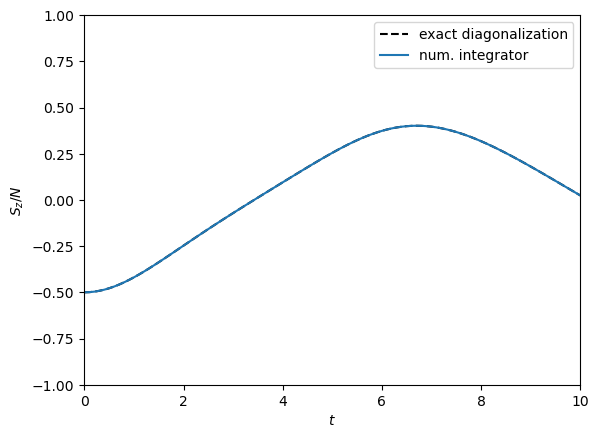

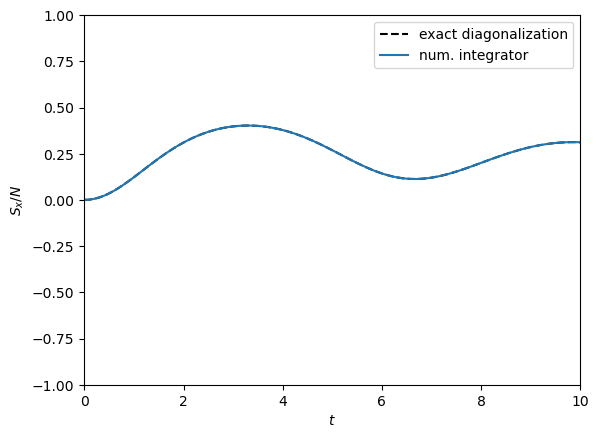

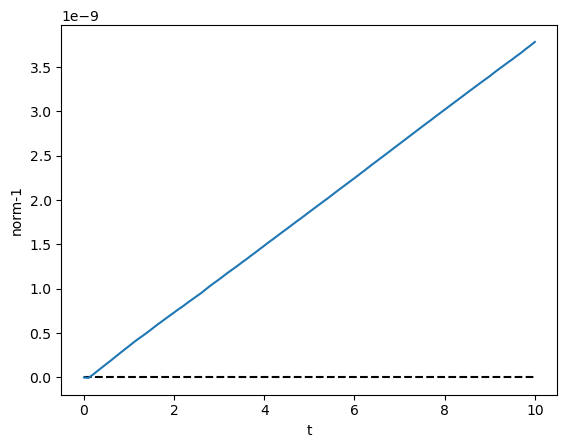

In [24]:
# initialize the integrator

y0, t0 = ini, 0

r = ode(cqd.integrators.schroedinger_diff_eq).set_integrator('zvode', method='adams', with_jacobian=False, rtol=1e-10, atol=1e-12)
r.set_initial_value(y0, t0).set_f_params(H_mat)

stepper_func = cqd.integrators.scipyODE_step
stepper_args = [r]
int_steps_per_dtout = 1

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

### Exercise 4 (optional)

Next, we want to check how the runtime for integrating our ODE scales with the number of spins N (or equivalently the Hilbert space dimension) and compare this to ED. Below is a code where you have to insert only your numerical integrator initialization and stepping.

For me, ED was still faster for up to N=1000 even for Arnoldi. Challenge: Try to find an integrator that beats my ED implementation :-)

Describe and interpret your observations. Play with step size and integrator order. Make sure that for the chosen integration step size the results are still accurate. (Eventually one would of course include an adaptive stepsize such that the local error is controlled!)

You can also try odeint (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html#scipy.integrate.odeint) and/or solve_ivp (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp). These modules are less object oriented and have a restricted choice of integrators but are somewhat easier to use. 

All the documentation pages have a lot of useful information about the integrators and even links to the original publications in which they were introduced.

In [25]:
# Compare ED to scipy.integrate.ode

dt = 0.1
tend = 10
tsteps = int(np.round(tend/dt))
tvec_output = cqd.utility.create_tvecs(tsteps, dt)

ome = 0.6

# running it to N=2000 takes a few minutes and starts to use significant memory (for testing, reduce this!)
N_vals = np.arange(200, 1001, 100) 

observables = np.zeros((2, 3, len(tvec_output), len(N_vals))) # for storing the results for Sz and Sx for all three methods (ED, scipy ODE integrator, and Arnoldi)
runtimes = np.zeros((4, len(N_vals))) # store time for H buildup, ED, numerical integration, and Arnoldi

scipyODE_stepper = cqd.integrators.scipyODE_step
Arnoldi_stepper = cqd.integrators.Arnoldi_step

for N_idx, N in enumerate(N_vals):
    
    print("N = ", N)
    ini = np.eye(1, int(N) + 1, 0)[0]
    
    t1 = time.time()
    Sz = cqd.operators.Sz_sparse(N)
    Sx = cqd.operators.Sx_sparse(N)
    obsv_vec = [Sz, Sx]

    H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
    t2 = time.time()
    runtimes[0, N_idx] = t2 - t1 # time for H matrix buildup, should be negligible

    # ED solution
    t1 = time.time()
    observables_ED = cqd.unitaries.calc_expv_ED(obsv_vec, H_mat, ini, tvec_output)
    t2 = time.time()
    runtimes[1, N_idx] = t2 - t1 # time for ED
    
    # store observables (for checking accuracy)
    observables[:, 0, :, N_idx] = observables_ED
    
    # scipyODE solution
    t1=time.time() # start run time measurement
   
    # set up the integrator
    t0 = 0
    r = ode(cqd.integrators.schroedinger_diff_eq).set_integrator('zvode', method='adams', with_jacobian=False, rtol=1e-10, atol=1e-12)
    r.set_initial_value(ini, t0).set_f_params(H_mat)
    
    stepper_args = [r]
    int_steps_per_dtout = 1
    
    # do the integration
    observables_Integrator = cqd.integrators.integrate_ODE(scipyODE_stepper, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)
    t2 = time.time() # end run time measurement
    runtimes[2, N_idx] = t2 - t1 # time for integration
    
    # store observables (for checking accuracy)
    observables[:, 1, :, N_idx] = observables_Integrator

    t1 = time.time() # start run time measurement for Arnoldi

    n = 20
    stepper_args = [n]

    int_steps_per_dtout = 3 # default for output time step is 0.1
    # do the integration
    observables_Integrator = cqd.integrators.integrate_ODE(Arnoldi_stepper, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)
    t2 = time.time()
    runtimes[3, N_idx] = t2 - t1 # time for integration

    # store observables (for checking accuracy)
    observables[:, 2, :, N_idx] = observables_Integrator

N =  200
time for ED was 0.03373551368713379
time for integration was 1.0211317539215088
time for integration was 0.51904296875
N =  300
time for ED was 0.03894662857055664
time for integration was 1.801255702972412
time for integration was 0.5334019660949707
N =  400
time for ED was 0.06055903434753418
time for integration was 2.021970272064209
time for integration was 0.8748488426208496
N =  500
time for ED was 0.1089777946472168
time for integration was 3.192251205444336
time for integration was 1.2750165462493896
N =  600
time for ED was 0.1512928009033203
time for integration was 4.714902400970459
time for integration was 0.6979551315307617
N =  700
time for ED was 0.16262412071228027
time for integration was 5.1221020221710205
time for integration was 0.7648181915283203
N =  800
time for ED was 0.23581838607788086
time for integration was 6.258289098739624
time for integration was 0.7460720539093018
N =  900
time for ED was 0.28269505500793457
time for integration was 8.749441862

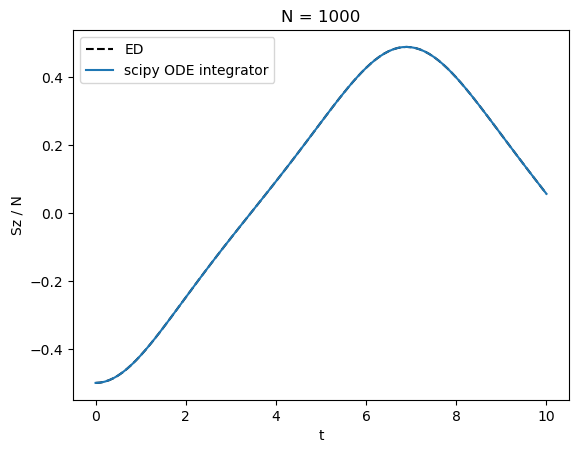

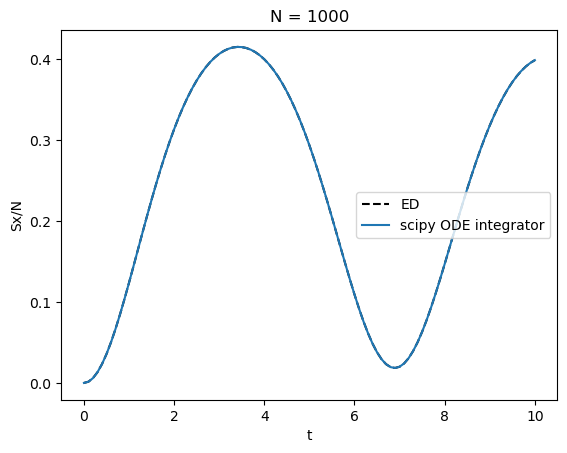

In [26]:
# plotting observables to check that integration was converged and accurate
N_idx=-1
plt.plot(tvec_output, observables[0, 0, :, N_idx] / N_vals[N_idx], 'k--', label='ED')
plt.plot(tvec_output, observables[0, 1, :, N_idx] / N_vals[N_idx], label='scipy ODE integrator')
plt.title('N = '+ str(N_vals[N_idx]))
plt.xlabel('t')
plt.ylabel('Sz / N')
plt.legend()
plt.show()

plt.plot(tvec_output, observables[1, 0, :, N_idx] / N_vals[N_idx], 'k--', label='ED')
plt.plot(tvec_output, observables[1, 1, :, N_idx] / N_vals[N_idx], label='scipy ODE integrator')
plt.title('N = '+ str(N_vals[N_idx]))
plt.xlabel('t')
plt.ylabel('Sx/N')
plt.legend()
plt.show()

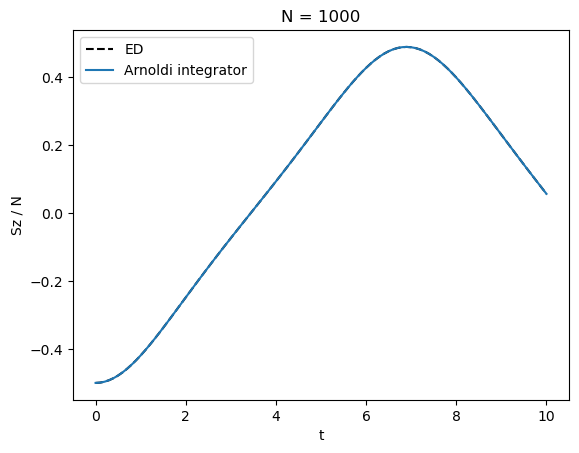

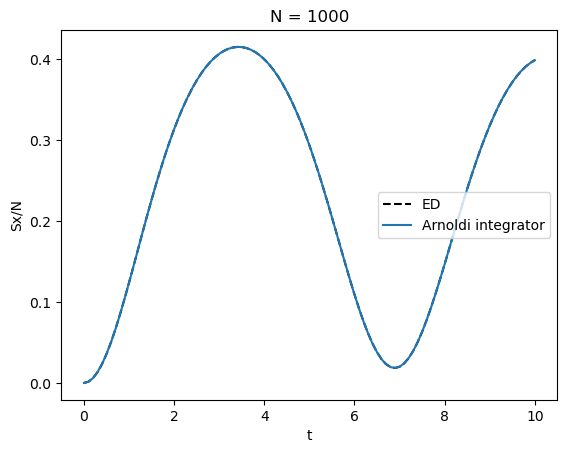

In [27]:
# plotting observables to check that integration was converged and accurate
N_idx=-1
plt.plot(tvec_output, observables[0, 0, :, N_idx] / N_vals[N_idx], 'k--', label='ED')
plt.plot(tvec_output, observables[0, 2, :, N_idx] / N_vals[N_idx], label='Arnoldi integrator')
plt.title('N = '+ str(N_vals[N_idx]))
plt.xlabel('t')
plt.ylabel('Sz / N')
plt.legend()
plt.show()

plt.plot(tvec_output, observables[1, 0, :, N_idx] / N_vals[N_idx], 'k--', label='ED')
plt.plot(tvec_output, observables[1, 2, :, N_idx] / N_vals[N_idx], label='Arnoldi integrator')
plt.title('N = '+ str(N_vals[N_idx]))
plt.xlabel('t')
plt.ylabel('Sx/N')
plt.legend()
plt.show()

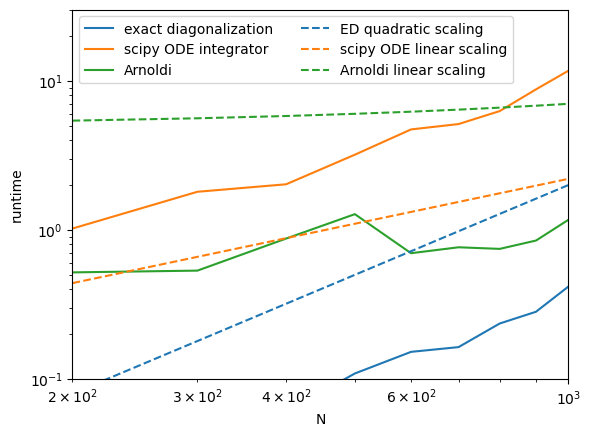

In [28]:
# plotting N-dependence of runtimes
plt.loglog(N_vals, runtimes[1], label = 'exact diagonalization')
plt.loglog(N_vals, runtimes[2], label = 'scipy ODE integrator')
plt.loglog(N_vals, runtimes[3], label = 'Arnoldi')
tab10 = plt.get_cmap('tab10').colors
plt.loglog(N_vals, 2 * 10 ** -6 * N_vals ** 2, color = tab10[0], linestyle = '--' , label = 'ED quadratic scaling')
plt.loglog(N_vals, 0.0022 * N_vals, color = tab10[1], linestyle = '--' , label = 'scipy ODE linear scaling')
plt.loglog(N_vals, 0.002 * N_vals + 5, color = tab10[2], linestyle = '--', label = 'Arnoldi linear scaling')

plt.ylim([10 ** -1, 3 * 10 ** 1])
plt.xlim([N_vals[0], N_vals[-1]])
plt.ylabel('runtime')
plt.xlabel('N')
plt.legend(ncols=2, loc='upper left')
plt.show()